# 1: Group patients by similar features

Use groups set up in previous notebook.

## Plain English summary

This notebook places the 10,000 patients in the test data into those 576 groups, and saves a record of the group assignments for later. 

## Load imports

In [1]:
import pandas as pd
import numpy as np

from dataclasses import dataclass

import matplotlib.pyplot as plt

# Turn warnings off to keep notebook tidy
import warnings
warnings.filterwarnings("ignore")

## Set up paths and filenames

In [2]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''

    data_read_path: str = '../../../stroke_utilities/data/'
    data_test_filename: str = 'cohort_10000_test_full.csv'
    data_train_filename: str = 'cohort_10000_train_full.csv'
    data_all_filename: str = 'reformatted_data_thrombolysis_decision.csv'
    data_save_path: str = '../../../stroke_utilities/data'
    notebook: str = ''

paths = Paths()

## Load groups

Also store a way to convert the number labels back to more meaningful labels:

In [3]:
mask_str_dict = {
    'onset_scan': {0: '<=4hr', 1: '>4hr'},
    'severity': {0: 'Mild', 1: 'Moderate', 2: 'Severe'},
    'mrs': {0: '0 to 1', 1: '2 to 3', 2: '4 to 5'},
    'age': {0: 'Below 80', 1: 'At least 80'},
    'infarction': {0: 'No', 1: 'Yes'},
    'precise': {0: 'No', 1: 'Yes'},
    'sleep': {0: 'No', 1: 'Yes'},
    'anticoag': {0: 'No', 1: 'Yes'},
    }

Load the mask combinations and their labels:

In [4]:
df_mask_numbers = pd.read_csv('mask_numbers.csv')

df_mask_numbers

,onset_scan_mask_number,severity_mask_number,mrs_mask_number,age_mask_number,infarction_mask_number,precise_mask_number,sleep_mask_number,anticoag_mask_number,mask_number
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,1
2,0,0,0,0,0,0,1,0,2
3,0,0,0,0,0,0,1,1,3
4,0,0,0,0,0,1,0,0,4
...,...,...,...,...,...,...,...,...,...
571,1,2,2,1,1,0,1,1,571
572,1,2,2,1,1,1,0,0,572
573,1,2,2,1,1,1,0,1,573
574,1,2,2,1,1,1,1,0,574


Translate the numbers back to strings for a better look:

In [5]:
masks_names = [c.replace('_mask_number', '') for c in df_mask_numbers.columns]

In [6]:
df_mask_labels = df_mask_numbers.copy()

# Remove the _mask_number part of the columns:
df_mask_labels = df_mask_labels.rename(
    columns=dict(zip([m + '_mask_number' for m in masks_names], masks_names))
)

# Replace numbers with labels:
df_mask_labels = df_mask_labels.replace(mask_str_dict)

df_mask_labels

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number
0,<=4hr,Mild,0 to 1,Below 80,No,No,No,No,0
1,<=4hr,Mild,0 to 1,Below 80,No,No,No,Yes,1
2,<=4hr,Mild,0 to 1,Below 80,No,No,Yes,No,2
3,<=4hr,Mild,0 to 1,Below 80,No,No,Yes,Yes,3
4,<=4hr,Mild,0 to 1,Below 80,No,Yes,No,No,4
...,...,...,...,...,...,...,...,...,...
571,>4hr,Severe,4 to 5,At least 80,Yes,No,Yes,Yes,571
572,>4hr,Severe,4 to 5,At least 80,Yes,Yes,No,No,572
573,>4hr,Severe,4 to 5,At least 80,Yes,Yes,No,Yes,573
574,>4hr,Severe,4 to 5,At least 80,Yes,Yes,Yes,No,574


## Load patient data

Import the patient data for all ~110,000 patients, not just the 10,000 test patients. 

In [7]:
filename = paths.data_read_path + paths.data_test_filename
test = pd.read_csv(filename)
test['data_source'] = 'test'

filename = paths.data_read_path + paths.data_train_filename
train = pd.read_csv(filename)
train['data_source'] = 'train'

filename = paths.data_read_path + paths.data_all_filename
all_data = pd.read_csv(filename)
all_data['data_source'] = 'all'
# Only keep rows that aren't in test or train data:
ids_to_keep = set(all_data['id']) - (set(train['id']) & set(test['id']))
all_data = all_data.loc[all_data['id'].isin(ids_to_keep)]
# Fill in missing values:
all_data['onset_to_thrombolysis'] = (
    all_data['onset_to_arrival_time'] + all_data['arrival_to_scan_time'])
all_data['any_afib_diagnosis'] = all_data['atrial_fibrillation']
all_data = all_data[[c for c in all_data.columns if c in train]]

data = pd.concat((train, test, all_data), axis='rows', ignore_index=True)

data = data.drop('year', axis=1)

In [8]:
for source in ['all', 'train', 'test']:
    print(f'{source:6s} {len(data[data["data_source"] == source]):6.0f}')

all    240530
train  104213
test    10000


## Place patients into groups

Before we set up a labelling system for all of the combinations of masks. Now we will actually find the mask belonging to each label.

The patient data is used and checked against each condition (e.g. is the stroke severity mild? Is it moderate? Is it severe?) and an answer of True or False is stored for each patient in every case. For the test data, each mask contains 10,000 True and False values.

The following cell creates a dictionary. The dictionary contains a list of masks for each feature. Each list is a different length depending on how many options there are for the feature.

In [9]:
masks_severity = [
    (data['stroke_severity'] < 8),
    ((data['stroke_severity'] >= 8) & (data['stroke_severity'] <= 32)),
    (data['stroke_severity'] > 32)
    ]
masks_mrs = [
    ((data['prior_disability'] == 0) | (data['prior_disability'] == 1)),
    ((data['prior_disability'] == 2) | (data['prior_disability'] == 3)),
    ((data['prior_disability'] == 4) | (data['prior_disability'] == 5)),
    ]
masks_age = [
    (data['age'] < 80),
    (data['age'] >= 80)
    ]
masks_infarction = [
    (data['infarction'] == 0),
    (data['infarction'] != 0)
    ]
masks_onset_scan = [
    (data['onset_to_arrival_time'] + data['arrival_to_scan_time'] <= 4*60),
    (data['onset_to_arrival_time'] + data['arrival_to_scan_time'] > 4*60)
    ]
masks_precise = [
    (data['precise_onset_known'] == 0),
    (data['precise_onset_known'] != 0)
    ]
masks_sleep = [
    (data['onset_during_sleep'] == 0),
    (data['onset_during_sleep'] != 0)
    ]
masks_anticoag = [
    (data['afib_anticoagulant'] == 0),
    (data['afib_anticoagulant'] != 0)
    ]

# Store the masks in a dictionary:
masks = {
    'onset_scan': masks_onset_scan,
    'severity': masks_severity,
    'mrs': masks_mrs,
    'age': masks_age,
    'infarction': masks_infarction,
    'precise': masks_precise,
    'sleep': masks_sleep,
    'anticoag': masks_anticoag
}
masks_names = list(masks.keys())
masks_lists = list(masks.values())
masks_cols = [f'{c}_mask_number' for c in masks_names]

For each of the 576 combinations of feature values, pick out the relevant masks from the above dictionary. Then multiply all eight of the chosen masks together. This means that only patients who answer True to each of the eight masks will end up as True in the combined mask.

This gives the complete ordered list of group number by patient.

In [10]:
# Start with a placeholder mask number:
group_masks = np.full(len(data), -42)

for n in df_mask_numbers['mask_number']:
    inds = df_mask_numbers.loc[df_mask_numbers['mask_number'] == n][masks_cols].values.flatten()
    # Patient assigned 1 if all masks are 1, else 0 (using np.product to multiply masks).
    all_masks_met = np.product([masks_lists[m][i] for m, i in enumerate(inds)], axis=0)
    if sum(group_masks[all_masks_met > 0]) > 0:
        print('Problem! Multiple groups assigned.', n)
    # Update the make number for these patients:
    group_masks[all_masks_met > 0] = n

data['mask_number'] = group_masks

Check that no patients are left with the placeholder value:

In [11]:
len(data[data['mask_number'] == -42])

0

Save a copy of the group assignments:

In [12]:
data.to_csv('all_data_group_assignments.csv', index=False)

## Checks

### Group sizes

Create a list of how many patients are in each group.

In [44]:
n_patients_per_group = data['mask_number'].value_counts()
n_patients_per_group.name = 'number_of_patients'

missing_groups = sorted(list(set(df_mask_numbers['mask_number']) - set(n_patients_per_group.index)))
for m in missing_groups:
    n_patients_per_group[m] = 0

In [14]:
df_mask_numbers = pd.merge(df_mask_numbers, n_patients_per_group, left_on='mask_number', right_index=True, how='left')
df_mask_labels = pd.merge(df_mask_labels, n_patients_per_group, left_on='mask_number', right_index=True, how='left')

How many groups contain zero patients? How many groups contain very few patients?

In [45]:
count_empty = len(n_patients_per_group[n_patients_per_group == 0.0])
count_low = len(n_patients_per_group[(
    (n_patients_per_group > 0) & (n_patients_per_group < 10) 
    )])

print(f'Number of empty groups: {count_empty}')
print(f'Number of small groups: {count_low}')

Number of empty groups: 151
Number of small groups: 71


Plot distribution of group sizes:

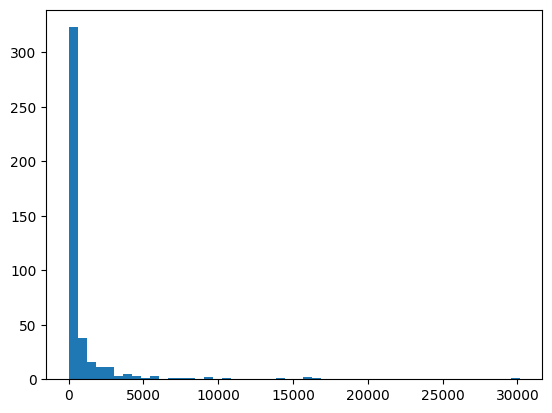

In [16]:
plt.hist(n_patients_per_group[n_patients_per_group > 0.0], bins=50)
plt.show()

Save a copy of how many patients are in each group.

In [23]:
data_sources = {
    'all': np.full(len(data), True),
    'train': data['data_source'] == 'train',
    'test': data['data_source'] == 'test',
}
list_mask_counts = []
for label, mask in data_sources.items():
    df_here = data.loc[mask, 'mask_number']
    df_here = df_here.value_counts().sort_index()
    df_here.name = label
    list_mask_counts.append(df_here)

df_mask_counts = pd.concat(list_mask_counts, axis='columns')
df_mask_counts = df_mask_counts.fillna(0).astype(int)

In [ ]:
missing_groups = sorted(list(set(df_mask_numbers['mask_number']) - set(df_mask_counts.index)))

for m in missing_groups:
    df_mask_counts.loc[m] = 0

df_mask_counts = df_mask_counts.sort_index()

In [30]:
df_mask_counts

,all,train,test
mask_number,,,
0,1080,495,45
1,742,335,36
2,108,53,1
3,82,37,4
4,2808,1271,133
...,...,...,...
571,3,0,0
572,15,0,0
573,4,0,0


In [31]:
df_mask_counts.to_csv('group_sizes.csv')

### Largest groups


Show the properties of the largest groups:

In [32]:
df_mask_labels.sort_values('number_of_patients', ascending=False)[:10]

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
12,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,No,No,12,30147
296,>4hr,Mild,0 to 1,Below 80,Yes,No,No,No,296,16715
13,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,No,Yes,13,15974
108,<=4hr,Moderate,0 to 1,Below 80,Yes,Yes,No,No,108,15848
300,>4hr,Mild,0 to 1,Below 80,Yes,Yes,No,No,300,14156
8,<=4hr,Mild,0 to 1,Below 80,Yes,No,No,No,8,10276
28,<=4hr,Mild,0 to 1,At least 80,Yes,Yes,No,No,28,9093
109,<=4hr,Moderate,0 to 1,Below 80,Yes,Yes,No,Yes,109,9092
297,>4hr,Mild,0 to 1,Below 80,Yes,No,No,Yes,297,8365
301,>4hr,Mild,0 to 1,Below 80,Yes,Yes,No,Yes,301,7369


### Empty groups

Show the properties of the size-zero groups:

In [33]:
df_mask_labels[df_mask_labels['number_of_patients'] == 0.0]

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
6,<=4hr,Mild,0 to 1,Below 80,No,Yes,Yes,No,6,0
7,<=4hr,Mild,0 to 1,Below 80,No,Yes,Yes,Yes,7,0
14,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,Yes,No,14,0
15,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,Yes,Yes,15,0
22,<=4hr,Mild,0 to 1,At least 80,No,Yes,Yes,No,22,0
...,...,...,...,...,...,...,...,...,...,...
559,>4hr,Severe,4 to 5,Below 80,Yes,Yes,Yes,Yes,559,0
566,>4hr,Severe,4 to 5,At least 80,No,Yes,Yes,No,566,0
567,>4hr,Severe,4 to 5,At least 80,No,Yes,Yes,Yes,567,0
574,>4hr,Severe,4 to 5,At least 80,Yes,Yes,Yes,No,574,0


Show all zero-size groups that do not have onset-to-scan above 4 hours or both precise onset time and onset during sleep. There is no easy logical reason why any remaining groups should have zero size.

In [34]:
mask = (
    (df_mask_labels['onset_scan'] == '>4hr') |
    ((df_mask_labels['precise'] == 'Yes') & (df_mask_labels['sleep'] == 'Yes'))
)
df_here = df_mask_labels[(df_mask_labels['number_of_patients'] == 0.0) & ~mask]

display(df_here)

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
219,<=4hr,Severe,0 to 1,At least 80,Yes,No,Yes,Yes,219,0
234,<=4hr,Severe,2 to 3,Below 80,Yes,No,Yes,No,234,0
259,<=4hr,Severe,4 to 5,Below 80,No,No,Yes,Yes,259,0
283,<=4hr,Severe,4 to 5,At least 80,Yes,No,Yes,Yes,283,0


How many groups have precise=yes and sleep=yes?

In [35]:
df_here = df_mask_labels[(df_mask_labels['precise'] == 'Yes') & (df_mask_labels['sleep'] == 'Yes')]

print('Total patients in these groups:', df_here['number_of_patients'].sum())
display(df_here)

Total patients in these groups: 0


,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
6,<=4hr,Mild,0 to 1,Below 80,No,Yes,Yes,No,6,0
7,<=4hr,Mild,0 to 1,Below 80,No,Yes,Yes,Yes,7,0
14,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,Yes,No,14,0
15,<=4hr,Mild,0 to 1,Below 80,Yes,Yes,Yes,Yes,15,0
22,<=4hr,Mild,0 to 1,At least 80,No,Yes,Yes,No,22,0
...,...,...,...,...,...,...,...,...,...,...
559,>4hr,Severe,4 to 5,Below 80,Yes,Yes,Yes,Yes,559,0
566,>4hr,Severe,4 to 5,At least 80,No,Yes,Yes,No,566,0
567,>4hr,Severe,4 to 5,At least 80,No,Yes,Yes,Yes,567,0
574,>4hr,Severe,4 to 5,At least 80,Yes,Yes,Yes,No,574,0


### Small groups

Show the properties of the small but non-zero groups:

In [36]:
df_small_groups = df_mask_labels[
    (df_mask_labels['number_of_patients'] > 0.0) &
    (df_mask_labels['number_of_patients'] < 10.0)
]
display(df_small_groups)

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
66,<=4hr,Mild,4 to 5,Below 80,No,No,Yes,No,66,2
67,<=4hr,Mild,4 to 5,Below 80,No,No,Yes,Yes,67,4
82,<=4hr,Mild,4 to 5,At least 80,No,No,Yes,No,82,2
83,<=4hr,Mild,4 to 5,At least 80,No,No,Yes,Yes,83,8
195,<=4hr,Severe,0 to 1,Below 80,No,No,Yes,Yes,195,8
...,...,...,...,...,...,...,...,...,...,...
564,>4hr,Severe,4 to 5,At least 80,No,Yes,No,No,564,4
565,>4hr,Severe,4 to 5,At least 80,No,Yes,No,Yes,565,6
570,>4hr,Severe,4 to 5,At least 80,Yes,No,Yes,No,570,5
571,>4hr,Severe,4 to 5,At least 80,Yes,No,Yes,Yes,571,3


How many have infarction=No?

In [37]:
len(df_small_groups[df_small_groups['infarction'] == 'No'])

40

Only show small groups with infarction:

In [38]:
df_small_groups[df_small_groups['infarction'] == 'Yes']

,onset_scan,severity,mrs,age,infarction,precise,sleep,anticoag,mask_number,number_of_patients
203,<=4hr,Severe,0 to 1,Below 80,Yes,No,Yes,Yes,203,6
218,<=4hr,Severe,0 to 1,At least 80,Yes,No,Yes,No,218,6
235,<=4hr,Severe,2 to 3,Below 80,Yes,No,Yes,Yes,235,2
250,<=4hr,Severe,2 to 3,At least 80,Yes,No,Yes,No,250,6
251,<=4hr,Severe,2 to 3,At least 80,Yes,No,Yes,Yes,251,2
266,<=4hr,Severe,4 to 5,Below 80,Yes,No,Yes,No,266,8
267,<=4hr,Severe,4 to 5,Below 80,Yes,No,Yes,Yes,267,2
269,<=4hr,Severe,4 to 5,Below 80,Yes,Yes,No,Yes,269,6
282,<=4hr,Severe,4 to 5,At least 80,Yes,No,Yes,No,282,6
490,>4hr,Severe,0 to 1,Below 80,Yes,No,Yes,No,490,8
